In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#import python require classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import os
import pickle
from sklearn.metrics import accuracy_score
from keras.utils.np_utils import to_categorical
from keras.layers import Dense, Dropout, Activation, Flatten, LSTM, RepeatVector
from keras.models import Sequential, load_model, Model
from sklearn.metrics import accuracy_score
from keras.callbacks import ModelCheckpoint
from sklearn import svm
from keras.layers import  MaxPooling2D
from keras.layers import Convolution2D
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.


In [3]:
#loading normal wify dataset
df1 = pd.read_csv("Dataset/normal.csv")
df1['Class'] = 0
df1

,freq1,noise,num_packets,delay,base_pwr_db,rssi,relpwr_db,avgpwr_db,Class
0,5805,-108,60,87,380,7,8,56,0
1,5805,-108,48,87,380,5,10,55,0
2,5805,-108,54,87,380,5,8,55,0
3,5805,-108,52,87,380,7,9,55,0
4,5805,-108,48,87,380,5,11,56,0
...,...,...,...,...,...,...,...,...,...
29995,5805,-108,71,90,377,5,10,58,0
29996,5805,-108,57,90,377,5,11,57,0
29997,5805,-108,55,90,377,3,9,57,0
29998,5805,-108,74,90,377,4,9,57,0


In [4]:
#loading wifi jamming attack dataset
df2 = pd.read_csv("Dataset/jamming_gaussiannoise.csv")
df2['Class'] = 1
df2

,freq1,noise,num_packets,delay,base_pwr_db,rssi,relpwr_db,avgpwr_db,Class
0,5805,-102,27,79,382,11,9,56,1
1,5805,-102,31,79,381,10,10,58,1
2,5805,-102,34,81,380,10,10,59,1
3,5805,-102,33,80,381,10,9,58,1
4,5805,-102,36,79,382,9,11,59,1
...,...,...,...,...,...,...,...,...,...
29995,5805,-102,43,62,398,25,14,59,1
29996,5805,-102,57,62,399,27,14,60,1
29997,5805,-102,53,61,400,27,14,59,1
29998,5805,-102,52,61,400,27,17,59,1


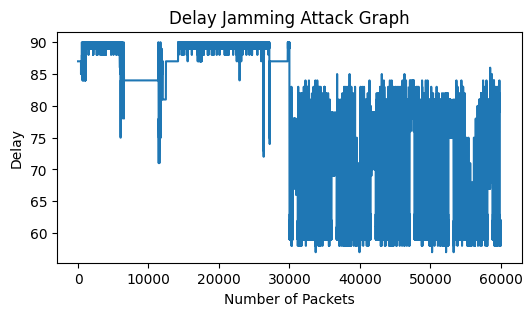

In [5]:
#combining both datasets to form a single dataset with normal and jamming attack
dataset = pd.concat([df1, df2])
plt.figure(figsize=(6, 3))
plt.plot(dataset['delay'].ravel())
plt.title("Delay Jamming Attack Graph")
plt.xlabel("Number of Packets")
plt.ylabel("Delay")
plt.show()

In [6]:
#apply dataset processing such as shuffling and normalization
data = dataset.values
X = data[:,0:data.shape[1]-1]
Y = data[:,data.shape[1]-1]
scaler = MinMaxScaler((0,1))
X = scaler.fit_transform(X)#normalize features
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle features
X = X[indices]
Y = Y[indices]
print("Normalize Features = "+str(X))

Normalize Features = [[1.         0.         0.31081081 ... 0.65853659 0.15873016 0.58064516]
 [1.         0.         0.31756757 ... 0.65853659 0.14285714 0.51612903]
 [1.         0.         0.29054054 ... 0.63414634 0.15873016 0.5483871 ]
 ...
 [0.968      1.         0.31756757 ... 0.81707317 0.03174603 0.51612903]
 [1.         1.         0.16891892 ... 0.93902439 0.23809524 0.5483871 ]
 [0.096      1.         0.25675676 ... 0.73170732 0.12698413 0.67741935]]


In [7]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Train & Test Split Details")
print("Number of records in Dataset : "+str(X.shape[0]))
print("Number of features found in Dataset : "+str(X.shape[1]))
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records used to test algorithms : "+str(X_test.shape[0]))

Dataset Train & Test Split Details
Number of records in Dataset : 60000
Number of features found in Dataset : 8
80% records used to train algorithms : 48000
20% records used to test algorithms : 12000


In [8]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [9]:
#function to calculate accuracy and other metrics
def calculateMetrics(algorithm, predict, y_test):
    labels = ['Normal', 'Jamming Attack']
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(4, 3)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()  

Existing SVM Accuracy  :  78.675
Existing SVM Precision : 78.67710168762862
Existing SVM Recall    : 78.67389222452434
Existing SVM FScore    : 78.6740757285182


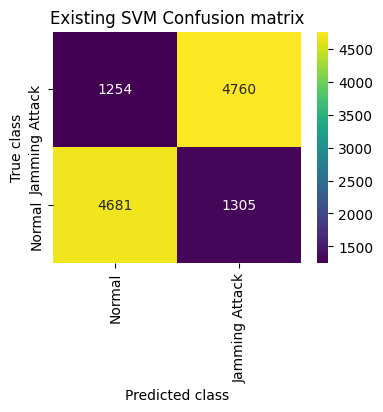

In [10]:
#training SVM algorithm on training features and then evaluating performance on 20% test features
svm_cls = svm.SVC(kernel='sigmoid')
svm_cls.fit(X_train, y_train)
predict = svm_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Existing SVM", predict, y_test)


Propose LSTM Accuracy  :  99.79166666666667
Propose LSTM Precision : 99.79214995770332
Propose LSTM Recall    : 99.79141275324722
Propose LSTM FScore    : 99.79166423463596


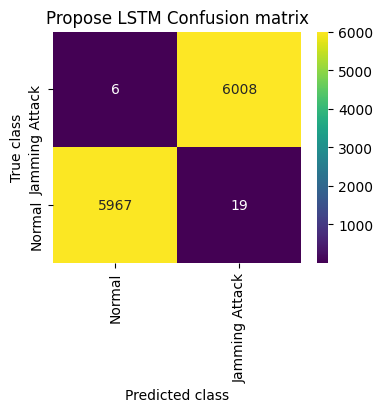

In [11]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_train.shape[1], 1))
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
#training propose LSTM algorithm on training features and then evaluating performance on 20% test features
lstm_model = Sequential()#defining deep learning sequential object
#adding LSTM layer with 100 filters to filter given input X train data to select relevant features
lstm_model.add(LSTM(100,input_shape=(X_train.shape[1], X_train.shape[2])))
#adding dropout layer to remove irrelevant features
lstm_model.add(RepeatVector(2))
lstm_model.add(LSTM(100))
#adding dropout layer to remove irrelevant features
lstm_model.add(Dropout(0.3))
#adding another layer
lstm_model.add(Dense(100, activation='relu'))
#defining output layer for prediction
lstm_model.add(Dense(y_train.shape[1], activation='softmax'))
#compile LSTM model
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
if os.path.exists("model/lstm_model.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_model.hdf5', verbose = 1, save_best_only = True)
    hist = lstm_model.fit(X_train, y_train, batch_size = 32, epochs = 25, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/lstm_hist.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    lstm_model.load_weights("model/lstm_model.hdf5")
#perform prediction on test data
predict = lstm_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Propose LSTM", predict, y_test1)


Extension CNN2D Accuracy  :  100.0
Extension CNN2D Precision : 100.0
Extension CNN2D Recall    : 100.0
Extension CNN2D FScore    : 100.0


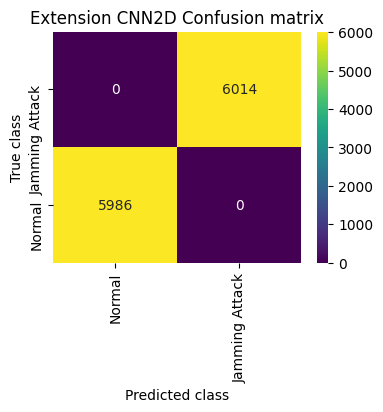

In [12]:
#training extension CNN2D (convolution neural network with 2 dimension)  on training features and then evaluating performance on 20% test features
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_train.shape[2], 1))
#creating CNN model object
cnn2d_model = Sequential()
#defining CNN2D layer with 8 neurons to filter features 8 times
cnn2d_model.add(Convolution2D(8, (1, 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
#max layer to collect optimize features from CNN2D layer
cnn2d_model.add(MaxPooling2D(pool_size = (1, 1)))
#defining another layer to further optimzie features
cnn2d_model.add(Convolution2D(4, (1, 1), activation = 'relu'))
cnn2d_model.add(MaxPooling2D(pool_size = (1, 1)))
#adding drop layer to ignore irrelevant features
#lstm_model.add(Dropout(0.5))
cnn2d_model.add(Flatten())
#defining output layer
cnn2d_model.add(Dense(units = 16, activation = 'relu'))
cnn2d_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and laoding model
cnn2d_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn2d_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn2d_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn2d_model.fit(X_train1, y_train, batch_size = 32, epochs = 25, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn2d_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn2d_model.load_weights("model/cnn2d_weights.hdf5")
#perform prediction on test data   
predict = cnn2d_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Extension CNN2D", predict, y_test1)

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
CNN+GRU Accuracy  :  100.0
CNN+GRU Precision : 100.0
CNN+GRU Recall    : 100.0
CNN+GRU FScore    : 100.0


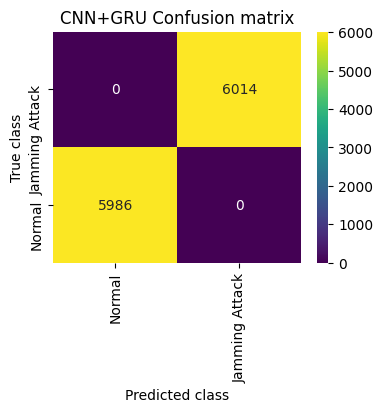

In [13]:
import numpy as np
import os
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D, MaxPooling2D, Flatten, Dense, Dropout, GRU, Reshape
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# ===== Data Preprocessing =====
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2], 1))

# ===== Model: CNN + GRU =====
model = Sequential()

# --- CNN Feature Extraction ---
model.add(Convolution2D(8, (1, 1), activation='relu', 
                        input_shape=(X_train1.shape[1], X_train1.shape[2], X_train1.shape[3])))
model.add(MaxPooling2D(pool_size=(1, 1)))

model.add(Convolution2D(4, (1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(1, 1)))

# Flatten spatial features but keep time dimension
model.add(Reshape((X_train1.shape[1], X_train1.shape[2] * 4)))  # 4 = filters from last Conv2D

# --- GRU for Sequence Learning ---
model.add(GRU(32, return_sequences=False))  # You can make it True if stacking more GRUs
model.add(Dropout(0.3))

# --- Output Layer ---
model.add(Dense(16, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))

# ===== Compile =====
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ===== Train or Load =====
if not os.path.exists("model/cnn_gru_weights.hdf5"):
    model_check_point = ModelCheckpoint(filepath='model/cnn_gru_weights.hdf5', verbose=1, save_best_only=True)
    hist = model.fit(X_train1, y_train, batch_size=32, epochs=25, 
                     validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    with open('model/cnn_gru_history.pckl', 'wb') as f:
        pickle.dump(hist.history, f)
else:
    model.load_weights("model/cnn_gru_weights.hdf5")

# ===== Prediction & Metrics =====
predict = model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)

calculateMetrics("CNN+GRU", predict, y_test1)


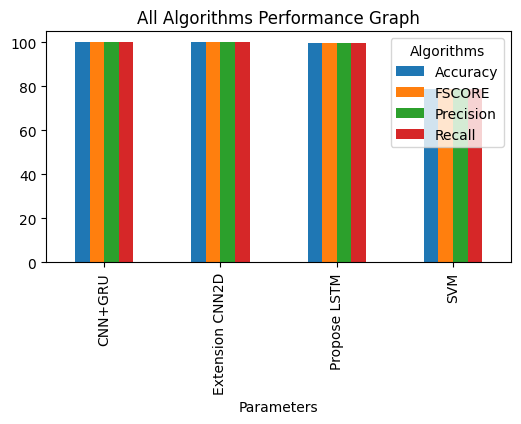

In [14]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['SVM','Accuracy',accuracy[0]],
                   ['SVM','Precision',precision[0]],
                   ['SVM','Recall',recall[0]],
                   ['SVM','FSCORE',fscore[0]],
                   ['Propose LSTM','Accuracy',accuracy[1]],
                   ['Propose LSTM','Precision',precision[1]],
                   ['Propose LSTM','Recall',recall[1]],
                   ['Propose LSTM','FSCORE',fscore[1]],
                   ['Extension CNN2D','Accuracy',accuracy[2]],
                   ['Extension CNN2D','Precision',precision[2]],
                   ['Extension CNN2D','Recall',recall[2]],
                   ['Extension CNN2D','FSCORE',fscore[2]],
                   ['CNN+GRU','Accuracy',accuracy[3]],
                   ['CNN+GRU','Precision',precision[3]],
                   ['CNN+GRU','Recall',recall[3]],
                   ['CNN+GRU','FSCORE',fscore[3]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [15]:
#display all algorithm performnace
algorithms = ['SVM', 'LSTM', 'CNN2D', 'CNN+GRU']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,SVM,78.675000,78.677102,78.673892,78.674076
1,LSTM,99.791667,99.792150,99.791413,99.791664
2,CNN2D,100.000000,100.000000,100.000000,100.000000
3,CNN+GRU,100.000000,100.000000,100.000000,100.000000


In [16]:
#function to read test data and then employ extension CNN2D to predict normal or Jamming attack
labels = ['Normal', 'Jamming Attack']
test_data = pd.read_csv("Dataset/testData.csv")#read test data values
temp = test_data.values
test_data = scaler.transform(temp)#normalize test data
test_data = np.reshape(test_data, (test_data.shape[0], test_data.shape[1], 1, 1))#convert data to CNN2D 2 dimension format
predict = cnn2d_model.predict(test_data)#perform prediction on test data
for i in range(len(predict)):
    y_pred = np.argmax(predict[i])
    print("Test Data = "+str(temp[i])+" Predicted Output ====> "+labels[y_pred])
    print()

Test Data = [5805 -106   71   90  375    3    8   57] Predicted Output ====> Normal

Test Data = [5805 -102   33   61  399   27   15   59] Predicted Output ====> Jamming Attack

Test Data = [5805 -108   55   84  383    6    8   53] Predicted Output ====> Normal

Test Data = [5805 -108   62   84  383    5    9   53] Predicted Output ====> Normal

Test Data = [5805 -102   31   60  401   28   15   58] Predicted Output ====> Jamming Attack

Test Data = [5805 -102   37   60  401   29   13   58] Predicted Output ====> Jamming Attack

Test Data = [5805 -106   53   90  375    4    6   57] Predicted Output ====> Normal

Test Data = [5805 -106   33   89  375    4   10   56] Predicted Output ====> Normal

Test Data = [5805 -106   32   90  375    4   10   58] Predicted Output ====> Normal

Test Data = [5805 -102   37   60  400   28   15   58] Predicted Output ====> Jamming Attack

Test Data = [5805 -102   39   61  399   26   14   59] Predicted Output ====> Jamming Attack

